# 02 — Difficulty Ranking

**Summary:** Ranks training examples by estimated difficulty using prompt and SVG complexity features from `src/svg/features` (`svg_complexity_features`, `prompt_complexity_features`, `weighted_rank_score`, `rank01`). Produces `train_ranked.csv` with difficulty scores and buckets for curriculum training (05) and easy-subset baselines (03–04).

**Prerequisite:** Prefer `data/interim/train_clean_basic.csv` from notebook 01; fall back to raw `train.csv` if needed.

**Parameters (defined in later cells)**

| Name | Role |
|------|------|
| `RANDOM_SEED` | Reproducibility for any sampling. |
| `svg_feature_weights` | Per-feature weights for SVG-derived difficulty (paths, tags, depth, etc.). |
| `prompt_feature_weights` | Per-feature weights for prompt difficulty (length, sentences, etc.). |
| `SVG_BLEND_WEIGHT` / `PROMPT_BLEND_WEIGHT` | Weights on ranked SVG vs prompt scores when forming `final_difficulty_score` (sum should be 1.0). |
| Output paths | `train_ranked.csv`, `train_curriculum_hint.csv` under `data/processed/`. |

**Workflow:** Load data → expand SVG/prompt features → combine scores → buckets and plots → save CSVs.


In [1]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Standard imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
# Define project paths
PROJECT_DIR = Path("/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL")

RAW_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for p in [PROJECT_DIR, RAW_DIR, INTERIM_DIR, PROCESSED_DIR, OUTPUTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


PROJECT_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL
RAW_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/raw
INTERIM_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/interim
PROCESSED_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/processed
FIGURES_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/figures


In [4]:
# Make project importable
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print("PROJECT_DIR appended to sys.path")


PROJECT_DIR appended to sys.path


In [5]:
# Import helper functions
from src.svg.features import (
    svg_complexity_features,
    prompt_complexity_features,
    rank01,
    weighted_rank_score,
)

print("Difficulty feature helpers imported successfully.")


Difficulty feature helpers imported successfully.


## Load cleaned training data

Prefer the interim file from notebook 01; resolve columns with the shared helper.


In [6]:
# Prefer the cleaned dataset from notebook 01 if it exists
TRAIN_CLEAN_PATH = INTERIM_DIR / "train_clean_basic.csv"
TRAIN_RAW_PATH = RAW_DIR / "train.csv"

if TRAIN_CLEAN_PATH.exists():
    train_df = pd.read_csv(TRAIN_CLEAN_PATH)
    source_path = TRAIN_CLEAN_PATH
else:
    train_df = pd.read_csv(TRAIN_RAW_PATH)
    source_path = TRAIN_RAW_PATH

print("Loaded training data from:", source_path)
print("train_df shape:", train_df.shape)


Loaded training data from: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/interim/train_clean_basic.csv
train_df shape: (50000, 14)


In [7]:
# Robust column detection (shared helper)
from src.core.dataframe import choose_first_existing

PROMPT_COL = choose_first_existing(train_df, ["prompt", "description", "text"], "train_df")
SVG_CANDIDATES = ["svg_clean", "svg", "target", "target_text", "svg_text", "code"]
SVG_COL = choose_first_existing(train_df, SVG_CANDIDATES, "train_df")

print("PROMPT_COL =", PROMPT_COL)
print("SVG_COL    =", SVG_COL)


PROMPT_COL = prompt
SVG_COL    = svg_clean


In [8]:
# Create a working copy
rank_df = train_df.copy()

# Basic missing-value handling
rank_df[PROMPT_COL] = rank_df[PROMPT_COL].fillna("").astype(str)
rank_df[SVG_COL] = rank_df[SVG_COL].fillna("").astype(str)

display(rank_df[[PROMPT_COL, SVG_COL]].head(3))


,prompt,svg_clean
0,"The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 L93.3000030517578..."
1,A simple smiley face with a wide open mouth and straight eyes.,"<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 C51.8089981079101..."
2,"The image features a black-outlined icon of a camera against a white background. The camera has a rectangular shape with rounded edges, a large circular lens in the center, and a smaller oval-shap...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703125 L41.405998229..."


## Compute SVG and prompt complexity features

Row-wise feature dicts merged into the main dataframe.


In [9]:
# SVG feature expansion
svg_feature_df = rank_df[SVG_COL].apply(svg_complexity_features).apply(pd.Series)

print("SVG feature columns:")
print(svg_feature_df.columns.tolist())
display(svg_feature_df.head())


SVG feature columns:
['num_paths', 'max_path_len', 'sum_path_len', 'sum_path_cmds', 'max_path_cmds', 'line_cmds', 'curve_cmds', 'arc_cmds', 'move_cmds', 'close_cmds', 'weighted_path_difficulty', 'num_circles', 'num_rects', 'num_ellipses', 'num_polygons', 'num_polylines', 'num_lines', 'num_text', 'num_groups', 'group_depth', 'num_uses', 'polygon_points', 'polyline_points', 'num_drawable_tags', 'num_numeric_tokens', 'has_transform', 'has_defs', 'has_linear_gradient', 'has_radial_gradient', 'has_clip_path', 'has_mask', 'has_filter', 'has_style', 'has_opacity', 'advanced_feature_count']


,num_paths,max_path_len,sum_path_len,sum_path_cmds,max_path_cmds,line_cmds,curve_cmds,arc_cmds,move_cmds,close_cmds,weighted_path_difficulty,num_circles,num_rects,num_ellipses,num_polygons,num_polylines,num_lines,num_text,num_groups,group_depth,num_uses,polygon_points,polyline_points,num_drawable_tags,num_numeric_tokens,has_transform,has_defs,has_linear_gradient,has_radial_gradient,has_clip_path,has_mask,has_filter,has_style,has_opacity,advanced_feature_count
0,3.0,2385.0,3877.0,101.0,61.0,74.0,11.0,0.0,8.0,8.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,250.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,4.0,968.0,2794.0,42.0,12.0,10.0,20.0,0.0,6.0,6.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,172.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,2.0,2322.0,3707.0,57.0,37.0,19.0,23.0,5.0,5.0,5.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,233.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,2.0,1106.0,2093.0,60.0,30.0,25.0,27.0,0.0,4.0,4.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,234.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Prompt feature expansion
prompt_feature_df = rank_df[PROMPT_COL].apply(prompt_complexity_features).apply(pd.Series)

print("Prompt feature columns:")
print(prompt_feature_df.columns.tolist())
display(prompt_feature_df.head())


Prompt feature columns:
['prompt_num_chars', 'prompt_num_tokens', 'prompt_num_color_words', 'prompt_num_relation_words', 'prompt_num_count_words', 'prompt_num_style_words', 'prompt_comma_count', 'prompt_and_count', 'prompt_with_count']


,prompt_num_chars,prompt_num_tokens,prompt_num_color_words,prompt_num_relation_words,prompt_num_count_words,prompt_num_style_words,prompt_comma_count,prompt_and_count,prompt_with_count
0,122,20,2,0,1,1,1,1,1
1,62,12,0,0,0,1,0,1,1
2,223,38,1,4,0,1,2,1,1
3,176,32,1,2,0,1,1,1,1
4,117,23,2,0,0,1,0,0,1


In [11]:
# Merge features back into a single frame
rank_df = pd.concat([rank_df, svg_feature_df, prompt_feature_df], axis=1)

print("Merged ranking dataframe shape:", rank_df.shape)


Merged ranking dataframe shape: (50000, 58)


## Feature summaries

Descriptive stats for key engineered columns.


In [12]:
svg_summary_cols = [
    "num_paths", "max_path_len", "sum_path_len", "sum_path_cmds", "max_path_cmds",
    "line_cmds", "curve_cmds", "arc_cmds", "move_cmds", "close_cmds",
    "weighted_path_difficulty", "num_circles", "num_rects", "num_ellipses",
    "num_polygons", "num_polylines", "num_lines", "num_text", "num_groups",
    "group_depth", "num_uses", "polygon_points", "polyline_points",
    "num_drawable_tags", "num_numeric_tokens", "advanced_feature_count"
]

prompt_summary_cols = [
    "prompt_num_chars", "prompt_num_tokens", "prompt_num_color_words",
    "prompt_num_relation_words", "prompt_num_count_words", "prompt_num_style_words",
    "prompt_comma_count", "prompt_and_count", "prompt_with_count"
]

display(rank_df[svg_summary_cols].describe().T)
display(rank_df[prompt_summary_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
num_paths,50000.0,2.41904,3.350467,0.0,1.0,1.0,3.0,256.0
max_path_len,50000.0,1658.46400,1396.624313,0.0,645.0,1320.0,2298.0,15765.0
sum_path_len,50000.0,2242.50366,1738.883704,0.0,880.0,1872.0,3256.0,15765.0
sum_path_cmds,50000.0,46.92916,35.186119,0.0,25.0,41.0,62.0,1280.0
max_path_cmds,50000.0,33.40878,24.652096,0.0,17.0,28.0,44.0,546.0
line_cmds,50000.0,17.68880,16.950776,0.0,7.0,14.0,24.0,768.0
curve_cmds,50000.0,14.67060,16.519776,0.0,1.0,10.0,23.0,362.0
arc_cmds,50000.0,4.99446,8.443986,0.0,0.0,0.0,8.0,200.0
move_cmds,50000.0,4.97668,5.160941,0.0,3.0,4.0,6.0,256.0
close_cmds,50000.0,4.59862,4.833283,0.0,2.0,4.0,6.0,256.0


,count,mean,std,min,25%,50%,75%,max
prompt_num_chars,50000.0,116.56376,64.188289,5.0,72.0,103.0,137.0,860.0
prompt_num_tokens,50000.0,19.71228,10.337909,1.0,12.0,17.0,24.0,136.0
prompt_num_color_words,50000.0,1.75374,1.152650,0.0,1.0,2.0,2.0,11.0
prompt_num_relation_words,50000.0,0.75728,1.109753,0.0,0.0,0.0,1.0,12.0
prompt_num_count_words,50000.0,0.42236,0.670538,0.0,0.0,0.0,1.0,7.0
prompt_num_style_words,50000.0,0.79314,0.756439,0.0,0.0,1.0,1.0,5.0
prompt_comma_count,50000.0,0.69678,0.980865,0.0,0.0,0.0,1.0,25.0
prompt_and_count,50000.0,0.43304,0.603460,0.0,0.0,0.0,1.0,6.0
prompt_with_count,50000.0,0.68762,0.540263,0.0,0.0,1.0,1.0,4.0


## Difficulty scoring design

We compute three related scores:
- `svg_difficulty_score`: based only on SVG structure/complexity
- `prompt_difficulty_score`: based only on prompt complexity
- `final_difficulty_score`: weighted combination of both

The final score is then converted into percentile rank, ordinal rank, and quartile-style difficulty bucket.


In [13]:
# Weight design for SVG difficulty
svg_feature_weights = {
    "num_paths": 1.3,
    "max_path_len": 1.0,
    "sum_path_len": 1.0,
    "sum_path_cmds": 1.3,
    "max_path_cmds": 0.9,
    "line_cmds": 0.6,
    "curve_cmds": 1.1,
    "arc_cmds": 1.2,
    "move_cmds": 0.3,
    "close_cmds": 0.2,
    "weighted_path_difficulty": 1.5,
    "num_polygons": 0.6,
    "num_polylines": 0.6,
    "polygon_points": 0.9,
    "polyline_points": 0.9,
    "num_drawable_tags": 1.0,
    "num_numeric_tokens": 1.1,
    "num_groups": 0.5,
    "group_depth": 0.8,
    "advanced_feature_count": 1.3,
    "has_transform": 0.7,
    "has_defs": 0.7,
    "has_linear_gradient": 0.8,
    "has_radial_gradient": 0.8,
    "has_clip_path": 0.8,
    "has_mask": 0.8,
    "has_filter": 0.8,
    "has_style": 0.4,
    "has_opacity": 0.4,
    "num_uses": 0.5,
}


In [14]:
# Weight design for prompt difficulty
prompt_feature_weights = {
    "prompt_num_chars": 1.0,
    "prompt_num_tokens": 1.2,
    "prompt_num_color_words": 0.6,
    "prompt_num_relation_words": 1.0,
    "prompt_num_count_words": 0.7,
    "prompt_num_style_words": 0.7,
    "prompt_comma_count": 0.8,
    "prompt_and_count": 0.8,
    "prompt_with_count": 0.6,
}


In [15]:
# Compute ranking scores
rank_df["svg_difficulty_score"] = weighted_rank_score(rank_df, svg_feature_weights)
rank_df["prompt_difficulty_score"] = weighted_rank_score(rank_df, prompt_feature_weights)

# Final weighted blend (named weights — adjust here)
SVG_BLEND_WEIGHT = 0.75
PROMPT_BLEND_WEIGHT = 0.25
rank_df["final_difficulty_score"] = (
    SVG_BLEND_WEIGHT * rank_df["svg_difficulty_score"] +
    PROMPT_BLEND_WEIGHT * rank_df["prompt_difficulty_score"]
)

# Percentile and ordinal rank
rank_df["difficulty_percentile"] = rank01(rank_df["final_difficulty_score"])
rank_df["difficulty_rank"] = rank_df["final_difficulty_score"].rank(
    ascending=True,
    method="first"
).astype(int)

# Bucket into four groups
rank_df["difficulty_bucket"] = pd.qcut(
    rank_df["final_difficulty_score"].rank(method="first"),
    q=4,
    labels=["easy", "medium_easy", "medium_hard", "hard"]
)

display(
    rank_df[
        [PROMPT_COL, "svg_difficulty_score", "prompt_difficulty_score",
         "final_difficulty_score", "difficulty_percentile",
         "difficulty_rank", "difficulty_bucket"]
    ].head(10)
)


,prompt,svg_difficulty_score,prompt_difficulty_score,final_difficulty_score,difficulty_percentile,difficulty_rank,difficulty_bucket
0,"The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.",0.610494,0.613619,0.611275,0.91234,45617,hard
1,A simple smiley face with a wide open mouth and straight eyes.,0.505907,0.359270,0.469247,0.41648,20824,medium_easy
2,"The image features a black-outlined icon of a camera against a white background. The camera has a rectangular shape with rounded edges, a large circular lens in the center, and a smaller oval-shap...",0.582565,0.754641,0.625584,0.93914,46957,hard
3,"The image displays a black icon with a photo-like rectangle containing a wavy line on the left side and a plus sign on the right side, all set against a transparent background.",0.539108,0.707843,0.581292,0.83680,41840,hard
4,Generate svg code for an image that looks like: a blue icon with a white arrow. Don't use markdown just give svg code,0.258795,0.484842,0.315306,0.02706,1353,easy
5,"An arrow pointing right emerges from a line loop, in a rounded square.",0.367130,0.375829,0.369305,0.11084,5542,easy
6,"The image features a teal circular outline containing a solid teal star at its center, set against a white background.",0.621673,0.554449,0.604867,0.89820,44910,hard
7,"A gray square icon with the text ""MOV"" and a small corner piece resembling a document.",0.575111,0.437982,0.540829,0.69150,34575,medium_hard
8,"The image features a stylized black silhouette of a crescent moon with wavy lines extending from the right side, set against a white background.",0.600091,0.576200,0.594118,0.87250,43625,hard
9,A simple black silhouette of a person against a white background.,0.443313,0.301376,0.407829,0.21340,10670,easy


## Inspect easiest and hardest examples

Qualitative sanity check at both ends of the difficulty scale.


In [16]:
# Easiest examples
easy_cols = [
    PROMPT_COL, SVG_COL,
    "svg_difficulty_score", "prompt_difficulty_score",
    "final_difficulty_score", "difficulty_bucket",
    "num_paths", "sum_path_cmds", "num_drawable_tags",
    "num_numeric_tokens", "advanced_feature_count", "prompt_num_tokens"
]

display(rank_df.sort_values("final_difficulty_score", ascending=True)[easy_cols].head(10))


,prompt,svg_clean,svg_difficulty_score,prompt_difficulty_score,final_difficulty_score,difficulty_bucket,num_paths,sum_path_cmds,num_drawable_tags,num_numeric_tokens,advanced_feature_count,prompt_num_tokens
2550,A solid black circle on a white background.,"<svg height=""256"" preserveAspectRatio=""xMidYMid meet"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><circle cx=""32"" cy=""32"" r=""30"" /></svg>",0.232645,0.217623,0.228889,easy,0.0,0.0,1.0,11.0,0.0,8
38864,A solid black rectangle.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m5 17h62v38h-62z"" stroke=""#000000"" stroke-linecap=""round"" stroke-linejoin=""round"" stroke-width=""2"" /...",0.255279,0.185905,0.237936,easy,1.0,5.0,1.0,15.0,0.0,4
36735,A black triangle pointing upwards.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m10.86 12l2.53 6.08-2.22.92-2.53-6.05-3.64 3.68v-15.53l10.95 10.89z"" /></svg>",0.257123,0.186667,0.239509,easy,1.0,5.0,1.0,21.0,0.0,5
33564,A black arrow pointing downwards.,"<svg fill=""none"" height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m0 1h16v12h-5l-3 3-3-3h-5z"" fill=""#000000"" /></svg>",0.258925,0.186563,0.240834,easy,1.0,7.0,1.0,19.0,0.0,5
42464,An upward-pointing arrow icon.,"<svg fill=""none"" height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m20 16-8-8-8 8"" stroke=""#000000"" stroke-linecap=""round"" stroke-linejoin=""round"" stroke-w...",0.250686,0.211298,0.240839,easy,1.0,1.0,1.0,16.0,0.0,4
11854,A black checkmark symbol on a white background.,"<svg fill=""none"" height=""256"" stroke=""#000000"" stroke-linecap=""round"" stroke-linejoin=""round"" stroke-width=""2"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m20 6-1...",0.250719,0.219807,0.242991,easy,1.0,1.0,1.0,16.0,0.0,8
41553,A black horizontal line on a white background.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m4 12h16"" fill=""none"" stroke=""#000000"" stroke-linecap=""round"" stroke-linejoin=""round"" stroke-width=""...",0.251858,0.219150,0.243681,easy,1.0,2.0,1.0,13.0,0.0,8
45250,An icon featuring an upward pointing arrow.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m16.77 12.81-.75-.75-6.04 6.04.75.75 5.28-5.28 5.26 5.26.75-.75-3.01-3.01z"" /></svg>",0.253736,0.215828,0.244259,easy,1.0,2.0,1.0,24.0,0.0,7
20732,A black checkmark symbol on a white background.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m15.42 1.77-8.83 13.49-4.92-4.39.67-.75 4.05 3.61 8.2-12.52.84.55z"" /></svg>",0.253412,0.219807,0.245011,easy,1.0,2.0,1.0,22.0,0.0,8
18252,The image shows a plain black circle.,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m15 8c0 3.87-3.13 7-7 7s-7-3.13-7-7 3.13-7 7-7 7 3.13 7 7zm0 0"" fill=""#2e3436"" /></svg>",0.264124,0.188605,0.245244,easy,1.0,5.0,1.0,31.0,0.0,7


In [17]:
# Hardest examples
display(rank_df.sort_values("final_difficulty_score", ascending=False)[easy_cols].head(10))


,prompt,svg_clean,svg_difficulty_score,prompt_difficulty_score,final_difficulty_score,difficulty_bucket,num_paths,sum_path_cmds,num_drawable_tags,num_numeric_tokens,advanced_feature_count,prompt_num_tokens
33981,"The image depicts a single black silhouette of a beer mug filled with liquid and topped with foam, set against a white background. The mug has a handle on the left side and two vertical white line...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#000000"" fill-opacity=""1.0"" filling=""0"" d=""M158.33299255371094 75.0 L75.0 75.0 L75.0 155.16700744...",0.675924,0.944158,0.742983,hard,2.0,119.0,2.0,422.0,1.0,61
30292,"The image features a simple black line drawing of an animal's head, likely a cow or pig, with two circular ears at the top, two small black eyes near the center, and a large oval nose with two sma...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M80.27300262451172 92.25199890136719 A6.548999786...",0.674199,0.922503,0.736275,hard,5.0,87.0,5.0,384.0,1.0,50
31369,"A mannequin bust features a peach-colored necklace with a vibrant pinkish-red cord adorned with two small orange beads, from which a prominent purple triangular pendant hangs. The mannequin itself...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#fff"" fill-opacity=""1.0"" filling=""0"" d=""M161.1417999267578 68.712890625 C156.55117797851562 67.36...",0.677640,0.896327,0.732312,hard,10.0,95.0,10.0,445.0,1.0,66
4114,"The image features a black outline of a simplified video game controller with a white background. The controller has two main sections: one with a plus sign (+) and a horizontal bar, and another w...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M153.70799255371094 161.718994140625 C136.0390014...",0.672403,0.903986,0.730299,hard,10.0,96.0,10.0,412.0,1.0,59
15461,"The image features a black icon of a computer window with a gear symbol in the bottom right corner against a white background. The window has a rectangular shape with rounded corners, and two smal...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M46.31399917602539 48.37900161743164 L55.68899917...",0.667111,0.919706,0.730260,hard,4.0,94.0,4.0,393.0,1.0,73
6957,"The image features two black circular shapes, each containing a currency symbol, positioned centrally against a white background. The circle on the left contains a white dollar sign ($), while the...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#010101"" fill-opacity=""1.0"" filling=""0"" d=""M89.02525329589844 62.11616134643555 C80.4320678710937...",0.661537,0.931820,0.729108,hard,4.0,106.0,4.0,438.0,1.0,75
46694,"A black-and-white icon depicting two simplified human figures rowing a boat on water. The figures are seated back-to-back, each holding an oar that extends into the water, creating ripples. The bo...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M70.87000274658203 55.5 A10.326000213623047 10.32...",0.687703,0.852921,0.729007,hard,4.0,111.0,4.0,432.0,1.0,62
3099,"The image shows a black line drawing of a laboratory setup featuring a round-bottom flask with a cross-shaped pattern on it, positioned on a flat, horizontal surface. The flask has a neck with a h...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M195.83299255371094 197.44200134277344

## Distribution plots

Histograms for component and final scores; bucket counts.


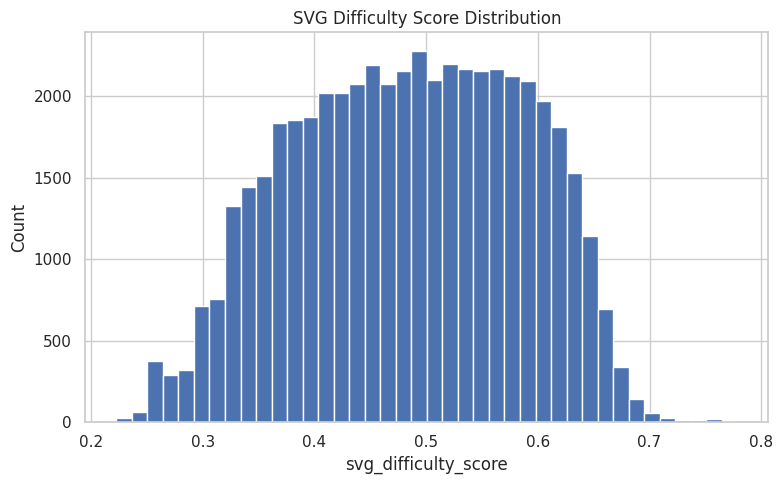

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(rank_df["svg_difficulty_score"], bins=40)
plt.title("SVG Difficulty Score Distribution")
plt.xlabel("svg_difficulty_score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "svg_difficulty_score_hist.png", dpi=150)
plt.show()


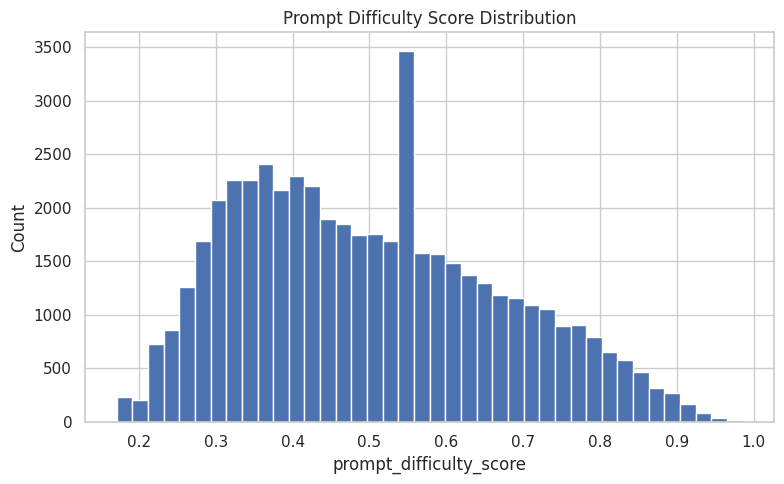

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(rank_df["prompt_difficulty_score"], bins=40)
plt.title("Prompt Difficulty Score Distribution")
plt.xlabel("prompt_difficulty_score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "prompt_difficulty_score_hist.png", dpi=150)
plt.show()


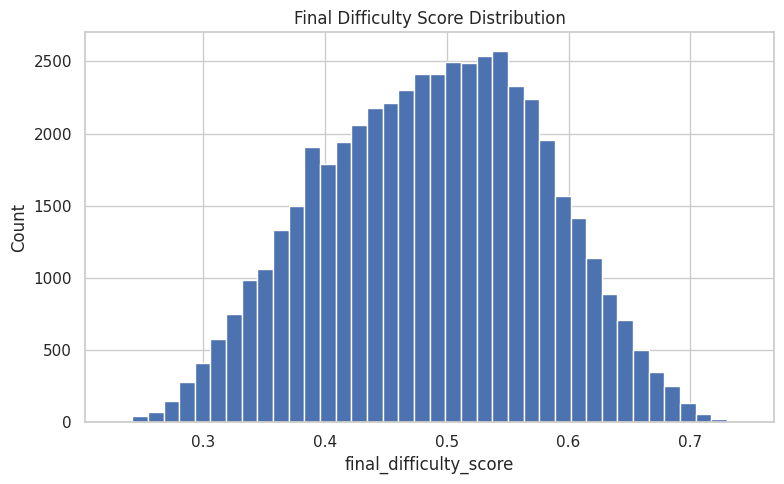

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(rank_df["final_difficulty_score"], bins=40)
plt.title("Final Difficulty Score Distribution")
plt.xlabel("final_difficulty_score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_difficulty_score_hist.png", dpi=150)
plt.show()


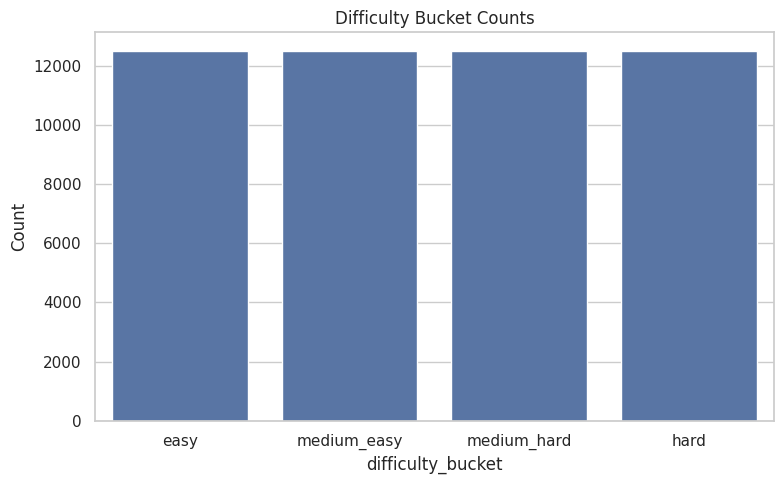

,count
difficulty_bucket,
easy,12500
medium_easy,12500
medium_hard,12500
hard,12500


In [21]:
bucket_counts = rank_df["difficulty_bucket"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=bucket_counts.index.astype(str), y=bucket_counts.values)
plt.title("Difficulty Bucket Counts")
plt.xlabel("difficulty_bucket")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "difficulty_bucket_counts.png", dpi=150)
plt.show()

display(bucket_counts.to_frame("count"))


## Correlation analysis

Linear relationships among difficulty components.


,svg_difficulty_score,prompt_difficulty_score,final_difficulty_score,num_paths,sum_path_cmds,weighted_path_difficulty,num_drawable_tags,num_numeric_tokens,advanced_feature_count,prompt_num_tokens,prompt_num_relation_words
svg_difficulty_score,1.000000,0.112355,0.887832,0.346726,0.774664,0.827204,0.180701,0.685669,0.244072,0.054351,0.093228
prompt_difficulty_score,0.112355,1.000000,0.557006,-0.072478,0.038384,0.045149,-0.056770,-0.007967,0.184634,0.878476,0.608467
final_difficulty_score,0.887832,0.557006,1.000000,0.256229,0.665240,0.712286,0.124740,0.569393,0.289500,0.452249,0.359701
num_paths,0.346726,-0.072478,0.256229,1.000000,0.548295,0.442875,0.843560,0.487728,-0.045670,-0.080974,-0.035343
sum_path_cmds,0.774664,0.038384,0.665240,0.548295,1.000000,0.951979,0.374134,0.842445,0.025486,0.003940,0.050609
weighted_path_difficulty,0.827204,0.045149,0.712286,0.442875,0.951979,1.000000,0.281076,0.889691,0.044569,0.008412,0.050060
num_drawable_tags,0.180701,-0.056770,0.124740,0.843560,0.374134,0.281076,1.000000,0.380322,0.013436,-0.034619,-0.092649
num_numeric_tokens,0.685669,-0.007967,0.569393,0.487728,0.842445,0.889691,0.380322,1.000000,-0.005210,-0.030797,0.006139
advanced_feature_count,0.244072,0.184634,0.289500,-0.045670,0.025486,0.044569,0.013436,-0.005210,1.000000,0.160326,0.074064
prompt_num_tokens,0.054351,0.878476,0.452249,-0.080974,0.003940,0.008412,-0.034619,-0.030797,0.160326,1.000000,0.581954


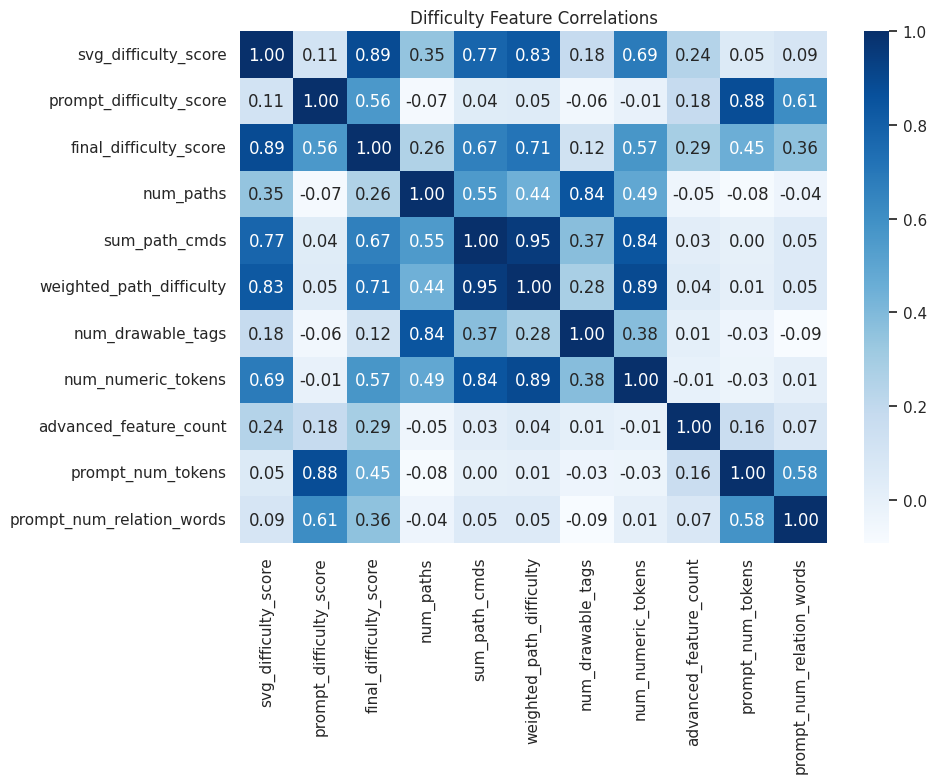

In [22]:
corr_cols = [
    "svg_difficulty_score", "prompt_difficulty_score", "final_difficulty_score",
    "num_paths", "sum_path_cmds", "weighted_path_difficulty",
    "num_drawable_tags", "num_numeric_tokens", "advanced_feature_count",
    "prompt_num_tokens", "prompt_num_relation_words"
]

corr_df = rank_df[corr_cols].corr(numeric_only=True)
display(corr_df)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Difficulty Feature Correlations")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "difficulty_feature_correlation_heatmap.png", dpi=150)
plt.show()


## Save ranked outputs

Write full ranked table and a compact curriculum-oriented subset.


In [23]:
# Save the full ranked dataset
ranked_out_path = PROCESSED_DIR / "train_ranked.csv"
rank_df.to_csv(ranked_out_path, index=False)

print(f"Saved ranked dataset to: {ranked_out_path}")


Saved ranked dataset to: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/processed/train_ranked.csv


In [24]:
# Save a lightweight curriculum view
curriculum_cols = [c for c in [
    PROMPT_COL, SVG_COL,
    "svg_difficulty_score", "prompt_difficulty_score",
    "final_difficulty_score", "difficulty_percentile",
    "difficulty_rank", "difficulty_bucket"
] if c in rank_df.columns]

curriculum_out_path = PROCESSED_DIR / "train_difficulty_curriculum.csv"
rank_df[curriculum_cols].to_csv(curriculum_out_path, index=False)

print(f"Saved curriculum dataset to: {curriculum_out_path}")


Saved curriculum dataset to: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/processed/train_difficulty_curriculum.csv


## Recommended downstream use

Typical next steps:
- train a baseline model on the full dataset
- train a curriculum variant that starts with easier buckets
- compare validation performance by difficulty bucket


## Note

Feature implementations are in `src/svg/features.py` (not a separate `difficulty_features` module).
